# Exercise 1: Linear and Logistic Regression with Error Estimation


## Instructions






### Setup check

Run the cell below before you begin. Every entry should report `found`.

In [41]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join("datasets", filename)
    status = "found" if os.path.isfile(path) else "MISSING"
    print(f"{filename:<16} {status}")

Python 3.12.13
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


---
# Part A. Linear regression

## Program 1. Ordinary least squares regression, from first principles and with `scikit-learn`

### Aim

To implement simple linear regression in Python without a machine learning library, to reproduce
the same fit using `scikit-learn`, and to attach an uncertainty estimate to the fitted
coefficients.

### Theory

The regression line is written as $y = b_0 + b_1 x$. The least squares estimates of the two
coefficients are

$$
\newcommand{\vect}{\mathbf}
\begin{align}
b_1 &= \frac{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})(y_i-\bar{y})}{\displaystyle \sum_{i=1}^{m}(x_i-\bar{x})^2}
= \frac{(\vect{x}-\bar{x})^T(\vect{y}-\bar{y})}{(\vect{x}-\bar{x})^T(\vect{x}-\bar{x})}
\\
b_0 &= \bar{y}-b_1\bar{x}
\end{align}
$$

The quality of the fit is summarised by

$$
\begin{align}
\text{RMSE} &= \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y_i})^2}
= \sqrt{\frac{(\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})}{m}}
\\
\text{SS}_{\text{tot}} &= \sum_{i=1}^{m}(y_i - \bar{y})^2 = (\vect{y}-\bar{y})^T(\vect{y}-\bar{y})
\\
\text{SS}_{\text{res}} &= \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 = (\vect{y}-\hat{\vect{y}})^T(\vect{y}-\hat{\vect{y}})
\\
R^{2} &= 1-\frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
\end{align}
$$

where $\vect{x} = (x_1,x_2,\dots,x_m)$ is the input vector, $\vect{y} = (y_1,y_2,\dots,y_m)$ is the
output vector, $\bar{x}$ and $\bar{y}$ are the corresponding means, and
$\hat{\vect{y}} = (\hat{y}_1,\hat{y}_2,\dots,\hat{y}_m)$ is the vector of predicted values.

Under the usual assumption of independent errors of constant variance, the standard errors of the
two coefficients follow from the residual variance
$s^2 = \text{SS}_{\text{res}}/(m-2)$:

$$
\begin{align}
\text{SE}(b_1) &= \sqrt{\frac{s^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}}
\\
\text{SE}(b_0) &= \sqrt{s^2\left[\frac{1}{m} + \frac{\bar{x}^2}{\sum_{i=1}^{m}(x_i-\bar{x})^2}\right]}
\end{align}
$$

The divisor $m-2$ appears because two parameters have already been estimated from the same data.

### TASK A1. Implementing the regression class

Complete the three methods of the class below. Use vectorised NumPy operations only, without an
explicit Python loop over the samples, and without importing `scikit-learn`.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        """Estimate b0 and b1 from one-dimensional arrays X and y.

        Stores the results as self.b0 and self.b1 and returns self.
        """
        m = X.shape[0]

        # TODO
        # 1. compute the means of X and y
        x_mean=np.mean(X);
        y_mean=np.mean(y);
        # 2. compute the mean-centred vectors
        x_centered=X-x_mean;
        y_centered=y-y_mean;
        # 3. obtain b1 from the ratio of the two inner products given in the theory section
        b1=np.dot(x_centered,y_centered)/np.dot(x_centered,x_centered);
        # 4. obtain b0 from b1 and the two means
        b0=y_mean-b1*x_mean;
        # 5. store them as self.b0 and self.b1
        self.b0=b0;
        self.b1=b1;


        # 6. print the pair in the format
        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self


    def predict(self, X):
        """Return the predicted response for the array X."""
        return self.b0 + self.b1 * X

        # TODO (1 mark)

    def evaluate(self, X, y):
        """Print and return the RMSE and the R^2 score as a tuple."""

        y_pred = self.predict(X)

        # TODO
        # compute rmse, ss_tot, ss_res and r2 using the formulae above
        rmse=np.sqrt(np.mean((y-y_pred)**2));
        y_mean = np.mean(y)
        ss_tot=np.sum((y-y_mean)**2);
        ss_res=np.sum((y-y_pred)**2);
        r2=1-ss_res/ss_tot;
        # then print them as
        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(r2, 3))
        #    and return the tuple (rmse, r2)
        return (rmse, r2)


### TASK A2. Plotting the fit

Complete the plotting helper. The scatter of the observed data and the fitted straight line must
appear on the same axes.

def regression_plot(X, y, model, title=""):
    """Scatter plot of the data with the fitted regression line drawn over it."""
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # TODO
    # 1. label the x axis as "Head size (cm^3)" and the y axis as "Brain weight (grams)"
    # 2. build a two-element array x_line spanning slightly beyond the data range,
    #    shaped as a column so that both implementations of predict() accept it
    # 3. evaluate the model on x_line to obtain y_line
    # 4. draw the observed points with plt.scatter and the fitted line with plt.plot
    # 5. add a legend and show the figure

    raise NotImplementedError("Task A2: complete regression_plot(), then delete this line")

In [50]:
def regression_plot(X, y, model, title=""):
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # 1.
    plt.xlabel("Head size (cm^3)")
    plt.ylabel("Brain weight (grams)")

    # 2.
    margin = (np.max(X) - np.min(X)) * 0.05
    x_line = np.array([np.min(X) - margin, np.max(X) + margin]).reshape(-1, 1)

    # 3.
    y_line = model.predict(x_line)

    # 4.
    plt.scatter(X, y, color="blue", alpha=0.5, label="Observed Data")
    plt.plot(x_line, y_line, color="red", linewidth=2, label="Fitted Regression Line")

    # 5.
    plt.legend()
    plt.show()

### TASK A3. Fitting the head and brain dataset

The dataset relates the head size of an adult to the mass of the brain. Load it, extract the two
columns of interest, fit the model, plot the result, and evaluate the fit.

In [51]:
# TODO : read datasets/headbrain.csv into a DataFrame named data,
data=pd.read_csv("./datasets/headbrain.csv");
# then print its shape and display the first five rows
print("Data shape:", data.shape)
data.head()


Data shape: (237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [52]:
# TODO : extract the predictor and the response as one-dimensional NumPy arrays
X = data["Head Size(cm^3)"].values   # column "Head Size(cm^3)"
y = data["Brain Weight(grams)"].values   # column "Brain Weight(grams)"


(b0, b1) = (325.573, 0.263)


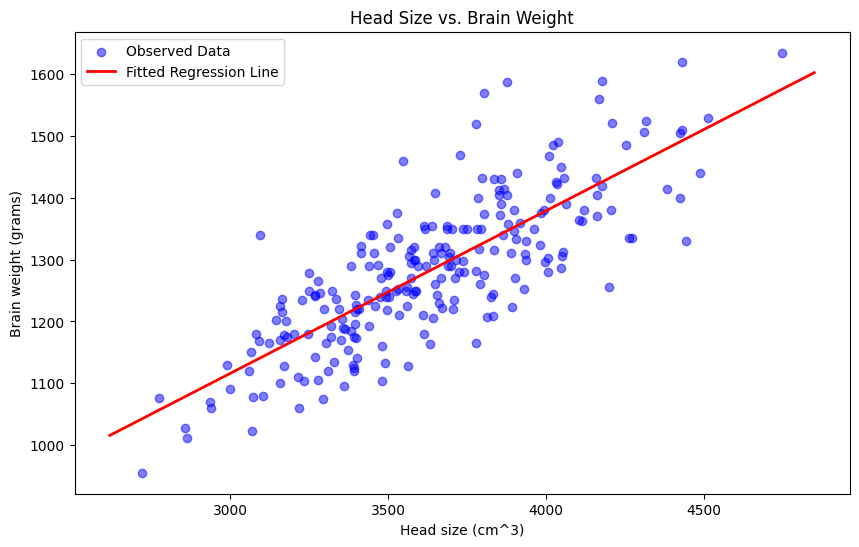

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.639311719957))

In [53]:
# TODO : create the model, fit it, plot the fit, and evaluate it
model = LinearRegression()
model.fit(X, y)
regression_plot(X, y, model, title="Head Size vs. Brain Weight")
model.evaluate(X, y)

### TASK A4. Comparison with `scikit-learn`

Repeat the fit with the library estimator and confirm that the two implementations agree.

Note that `scikit-learn` expects a two-dimensional array of predictors, so the input has to be
reshaped from `(m,)` to `(m, 1)`.

In [54]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

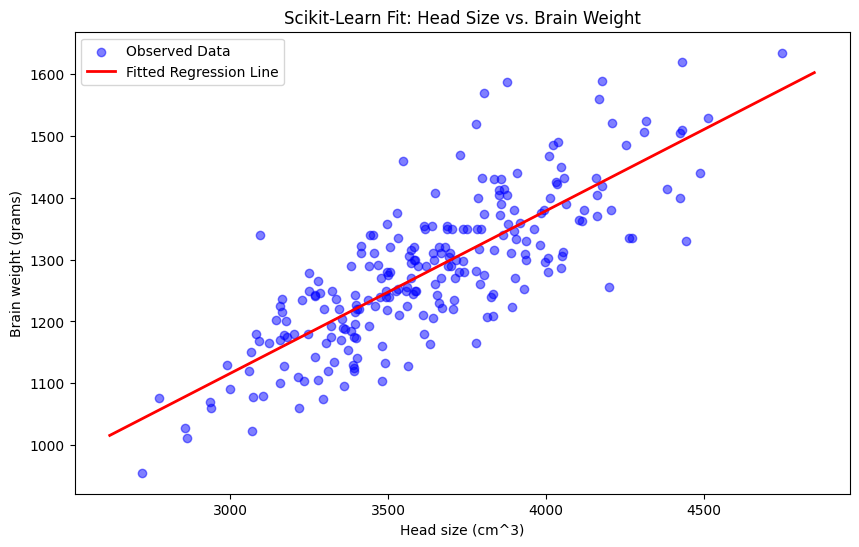

Scikit-learn (b0, b1): (325.573, 0.263)
Scikit-learn RMSE: 72.121
Scikit-learn R^2 value: 0.639
------------------------------
Absolute difference in b0: 2.2737367544323206e-13
Absolute difference in b1: 5.551115123125783e-17


In [55]:
# TODO

# 1. Fit SkLinearRegression on X1 and y
sk_model = SkLinearRegression()
sk_model.fit(X1, y)

# 2. Reuse regression_plot to display the fit
regression_plot(X1, y, sk_model, title="Scikit-Learn Fit: Head Size vs. Brain Weight")

# 3. Print the intercept and the coefficient, the RMSE, and the R^2 score
sk_b0 = sk_model.intercept_
sk_b1 = sk_model.coef_[0]
y_pred_sk = sk_model.predict(X1)

sk_rmse = np.sqrt(mean_squared_error(y, y_pred_sk))
sk_r2 = sk_model.score(X1, y)

print(f"Scikit-learn (b0, b1): ({sk_b0:.3f}, {sk_b1:.3f})")
print(f"Scikit-learn RMSE: {sk_rmse:.3f}")
print(f"Scikit-learn R^2 value: {sk_r2:.3f}")

# 4. Print the absolute difference between your own b0, b1 and the library values
diff_b0 = abs(model.b0 - sk_b0)
diff_b1 = abs(model.b1 - sk_b1)

print("-" * 30)
print(f"Absolute difference in b0: {diff_b0}")
print(f"Absolute difference in b1: {diff_b1}")

### TASK A5. Error estimation

A coefficient reported without an uncertainty is of limited scientific value. In this task the
uncertainty is estimated in two independent ways, first from the analytical expressions given in
the theory section and then by resampling.

The 95 per cent confidence interval of a coefficient is approximated as
$b \pm t_{0.975,\,m-2}\,\text{SE}(b)$, where the critical value is close to 1.96 for a sample of
this size.

In [56]:
def coefficient_standard_errors(X, y, model):
    # Return (se_b0, se_b1) for a fitted simple linear regression model.
    m = X.shape[0]

    # TODO
    # 1. Obtain the residuals y - model.predict(X)
    y_pred = model.predict(X)
    residuals = y - y_pred
    # 2. Compute the residual variance s^2 with the correct number of degrees of freedom (m - 2)
    s_squared = np.dot(residuals, residuals) / (m - 2)

    # 3. Compute the two standard errors from the expressions in the theory section
    x_mean = np.mean(X)
    x_centered = X - x_mean
    sum_sq_x = np.dot(x_centered, x_centered) # Denominator for both SE formulas

    se_b1 = np.sqrt(s_squared / sum_sq_x)
    se_b0 = np.sqrt(s_squared * (1/m + (x_mean**2) / sum_sq_x))

    return se_b0, se_b1



# TODO: report b0 and b1 together with their standard errors and their 95 per cent
# confidence intervals, in the form  b1 = 0.263 +/- 0.010
se_b0, se_b1 = coefficient_standard_errors(X, y, model)

ci_b1_lower, ci_b1_upper = model.b1 - 1.96 * se_b1, model.b1 + 1.96 * se_b1
ci_b0_lower, ci_b0_upper = model.b0 - 1.96 * se_b0, model.b0 + 1.96 * se_b0

print(f"b1 = {model.b1:.3f} +/- {se_b1:.3f} (95% CI: [{ci_b1_lower:.3f}, {ci_b1_upper:.3f}])")
print(f"b0 = {model.b0:.3f} +/- {se_b0:.3f} (95% CI: [{ci_b0_lower:.3f}, {ci_b0_upper:.3f}])")

b1 = 0.263 +/- 0.013 (95% CI: [0.238, 0.289])
b0 = 325.573 +/- 47.141 (95% CI: [233.177, 417.969])


(b0, b1) = (378.726, 0.248)
(b0, b1) = (331.318, 0.263)
(b0, b1) = (280.077, 0.276)
(b0, b1) = (271.900, 0.277)
(b0, b1) = (337.163, 0.260)
(b0, b1) = (302.642, 0.270)
(b0, b1) = (279.532, 0.275)
(b0, b1) = (292.682, 0.273)
(b0, b1) = (379.985, 0.250)
(b0, b1) = (279.597, 0.277)
(b0, b1) = (397.224, 0.242)
(b0, b1) = (366.474, 0.251)
(b0, b1) = (295.008, 0.273)
(b0, b1) = (380.039, 0.248)
(b0, b1) = (341.499, 0.258)
(b0, b1) = (415.911, 0.242)
(b0, b1) = (341.483, 0.259)
(b0, b1) = (340.068, 0.261)
(b0, b1) = (315.099, 0.267)
(b0, b1) = (368.813, 0.251)
(b0, b1) = (342.090, 0.259)
(b0, b1) = (259.536, 0.280)
(b0, b1) = (355.545, 0.257)
(b0, b1) = (324.950, 0.263)
(b0, b1) = (315.215, 0.267)
(b0, b1) = (246.109, 0.284)
(b0, b1) = (285.787, 0.276)
(b0, b1) = (361.210, 0.254)
(b0, b1) = (357.297, 0.254)
(b0, b1) = (370.527, 0.251)
(b0, b1) = (291.618, 0.273)
(b0, b1) = (318.630, 0.264)
(b0, b1) = (336.631, 0.261)
(b0, b1) = (399.243, 0.242)
(b0, b1) = (394.947, 0.245)
(b0, b1) = (325.733,

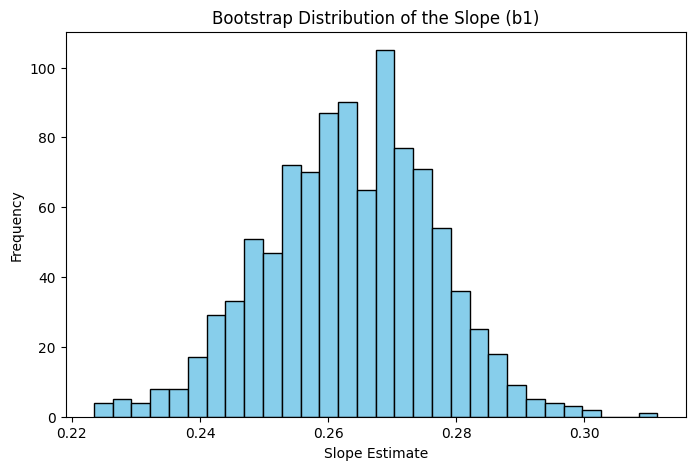

------------------------------
Analytical SE(b1): 0.01291
Bootstrap SE(b1):  0.01315


In [57]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    # Return an array of slope estimates from n_resamples bootstrap replicates.
    rng = np.random.default_rng(seed)
    m = X.shape[0]
    slopes = np.zeros(n_resamples)

    for i in range(n_resamples):
        # 1. Draw an index array of size m with replacement using rng.integers
        indices = rng.integers(0, m, size=m)

        # 2. Fit the model to the resampled data and store the slope
        X_resampled = X[indices]
        y_resampled = y[indices]

        # Initialize a new model, fit it, and extract the slope
        boot_model = LinearRegression()
        boot_model.fit(X_resampled, y_resampled)
        slopes[i] = boot_model.b1

    return slopes

slopes_array = bootstrap_slope(X, y)

# Plot a histogram of the bootstrap slopes
plt.figure(figsize=(8, 5))
plt.hist(slopes_array, bins=30, color='skyblue', edgecolor='black')
plt.title("Bootstrap Distribution of the Slope (b1)")
plt.xlabel("Slope Estimate")
plt.ylabel("Frequency")
plt.show()

# Print their standard deviation and compare it with the analytical SE(b1)
bootstrap_se_b1 = np.std(slopes_array)

print("-" * 30)
print(f"Analytical SE(b1): {se_b1:.5f}")
print(f"Bootstrap SE(b1):  {bootstrap_se_b1:.5f}")

### TASK A6. Written questions

Answer in the cell below.

1. The fitted slope carries physical units. State them and explain in one sentence what the slope
   means for this dataset.
2. The value of $R^2$ obtained here is well below unity. Give two distinct reasons why a single
   predictor cannot account for all of the variance in the response.
3. Suppose the head size were reported in cubic metres instead of cubic centimetres. State how
   $b_0$, $b_1$, RMSE, and $R^2$ would each change.

**ANSWER A6**

1. Units: grams per cubic centimetre (g/cm³).
   The slope (b1) represents the expected increase in brain weight (in grams) for every additional 1 cm³ increase in head size.

2. Missing Variables (Latent Features): Brain weight is not solely determined by head volume. Other factors like the density of the brain tissue, the age of the individual, sex, and general genetics all play a role. A simple linear regression with only one predictor cannot capture this missing biological complexity.


Measurement Error and Natural Variation: No two biological specimens are exactly alike, meaning there is natural variance (noise) in the data. Furthermore, physical measurements of head volume and brain mass carry inherent instrumental or observational errors

3. b1 (Slope): It would increase by a factor of 1,000,000. Because the x units are now a million times larger per single unit of measurement, the expected change in y for every "1 unit" increase in x (which is now a whole cubic metre) must scale up proportionally.


b0 (Intercept): It would remain unchanged. The intercept is the predicted brain weight when the head size is exactly zero. Zero cubic centimetres is exactly the same physical volume as zero cubic metres.


RMSE: It would remain unchanged. RMSE is measured in the units of the target variable (y), which is still grams. The physical distance between the data points and the regression line has not changed, only the scale of the x-axis has.


R²: It would remain unchanged. R² is a unitless, standardized ratio of explained variance. Linearly scaling a variable shifts the axis, but it does not change the underlying correlation or predictive power of the model.

---
# Part B. Logistic regression

## Program 1. Preprocessing and classification on the Titanic dataset with `scikit-learn`

### Aim

To prepare a dataset that contains missing values and categorical columns, and to fit and evaluate
a logistic regression classifier on it.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("./datasets/titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### TASK B1. Exploratory visualisation

The helper below draws a single titled figure. Use it to produce the six plots listed in the
comments.

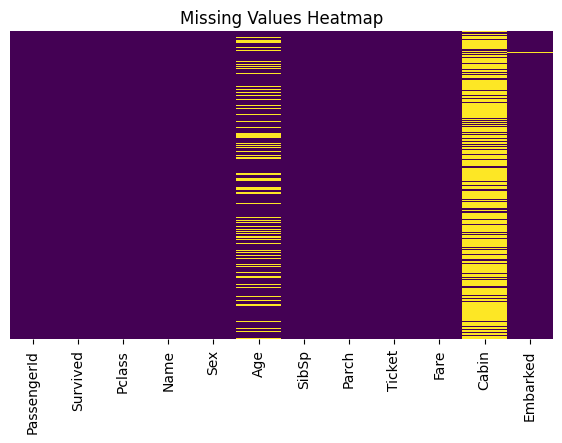

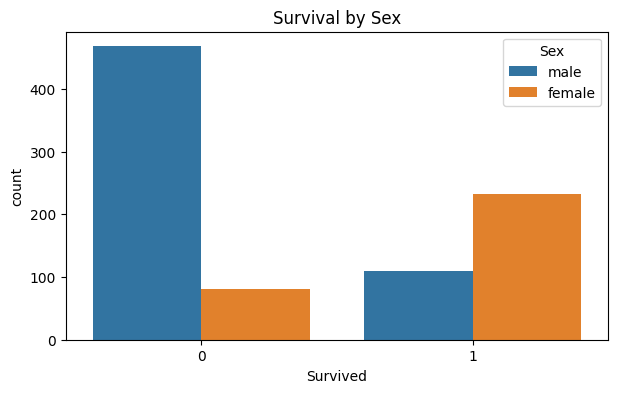

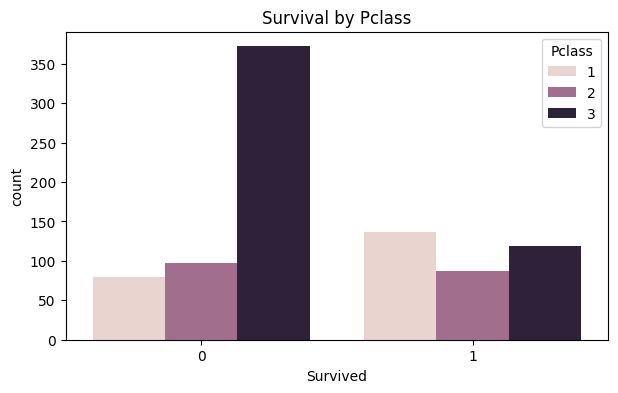

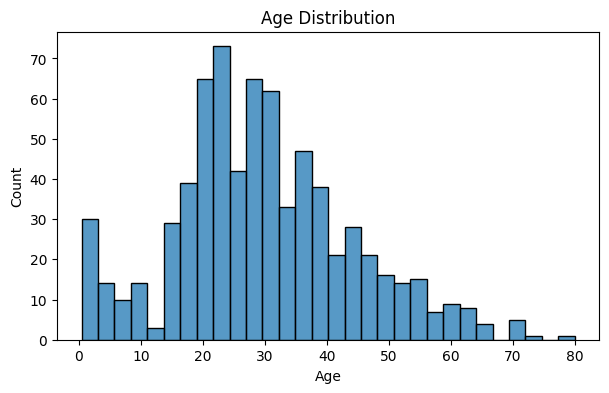

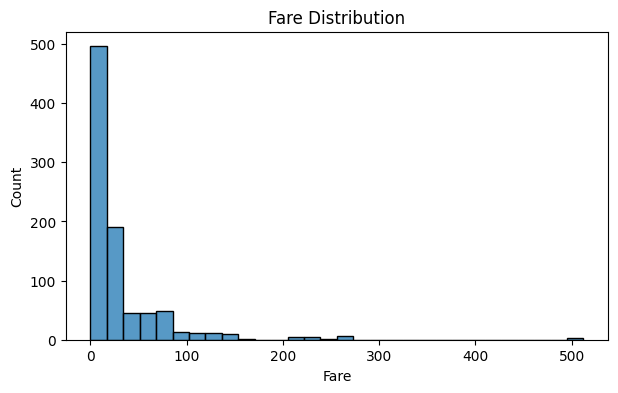

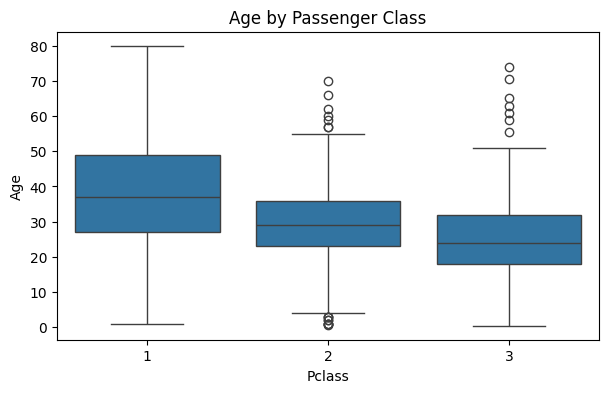

In [59]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()


# TODO : produce the following six figures using the helper above
# 1. a heatmap of titanic_df.isnull() to reveal which columns carry missing values
plot("Missing Values Heatmap", sns.heatmap, titanic_df.isnull(), yticklabels=False, cbar=False, cmap="viridis")

# 2. a count plot of Survived split by Sex
plot("Survival by Sex", sns.countplot, data=titanic_df, x="Survived", hue="Sex")

# 3. a count plot of Survived split by Pclass
plot("Survival by Pclass", sns.countplot, data=titanic_df, x="Survived", hue="Pclass")

# 4. a histogram of Age, with the missing entries dropped
plot("Age Distribution", sns.histplot, titanic_df["Age"].dropna(), bins=30)

# 5. a histogram of Fare
plot("Fare Distribution", sns.histplot, titanic_df["Fare"], bins=30)

# 6. a box plot of Age against Pclass
plot("Age by Passenger Class", sns.boxplot, data=titanic_df, x="Pclass", y="Age")


**ANSWER B1.** State which columns carry missing values, and describe in two or three sentences
what the box plot of age against passenger class reveals.

The columns that carry missing values are Age, Cabin, and Embarked. The box plot of age against passenger class reveals that the median age decreases as the class number increases. First-class passengers tend to be the oldest, while third-class passengers are generally the youngest.

### TASK B2. Missing, categorical, and irrelevant columns

Missing ages are filled with the mean age of the passenger class rather than with the mean of the
whole column, because age and class are correlated. Complete the imputation, then encode the
categorical columns and remove the columns that carry no predictive value.

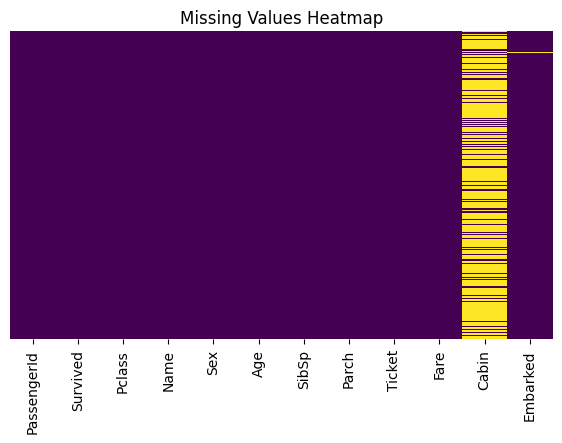

In [60]:
# TODO
# 1. build a dictionary mean_ages mapping each passenger class to the mean age within that class
# 2. complete impute_missing_age so that a missing age is replaced by the class mean
#    and an age that is already present is returned unchanged
# 3. apply it along axis 1 to the two columns Age and Pclass
# 4. redraw the missing value heatmap to confirm that the Age column is now complete

mean_ages = titanic_df.groupby('Pclass')['Age'].mean().to_dict()

def impute_missing_age(columns):
    age, p_class = columns
    if pd.isnull(age):
        return mean_ages[p_class]
    return age

titanic_df["Age"] = titanic_df[["Age", "Pclass"]].apply(impute_missing_age, axis=1)

plot("Missing Values Heatmap", sns.heatmap, titanic_df.isnull(), yticklabels=False, cbar=False, cmap="viridis")


In [61]:
# TODO
# 1. drop the Cabin column, which is missing for most passengers, then drop the remaining
#    rows that still contain a missing value
# 2. one-hot encode Sex and Embarked with pd.get_dummies, passing drop_first=True,
#    and concatenate the result to the frame
# 3. drop Name, PassengerId, Ticket, Sex, and Embarked
# 4. display the first five rows of the processed frame
titanic_df = titanic_df.drop('Cabin', axis=1)
titanic_df = titanic_df.dropna()

dummies = pd.get_dummies(titanic_df[['Sex', 'Embarked']], drop_first=True)
titanic_df = pd.concat([titanic_df, dummies], axis=1)

titanic_df = titanic_df.drop(['Name', 'PassengerId', 'Ticket', 'Sex', 'Embarked'], axis=1)
titanic_df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


**ANSWER B2.** Explain why `drop_first=True` is used when the categorical columns are encoded,
and what would go wrong if all of the indicator columns were retained.

drop_first=True is used to prevent multicollinearity, also known as the dummy variable trap. If all indicator columns are retained, one column can be perfectly predicted by the others. This breaks the mathematical assumptions of logistic regression and prevents the model from estimating independent weights.

### TASK B3. Fitting and evaluating the classifier

Scale `Age` and `Fare` to the unit interval before fitting, so that the two columns of large
numerical range do not dominate the optimisation. Fix `random_state` in the split so that your
result is reproducible.

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale


# 1. rescale the Age and Fare columns with minmax_scale
titanic_df[['Age', 'Fare']] = minmax_scale(titanic_df[['Age', 'Fare']])

# 2. separate the predictors X from the target y, which is the Survived column
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# 3. split into training and test sets with test_size=0.3 and a fixed random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. fit a LogisticRegression model and predict on the test set
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. print the classification report and the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[139  28]
 [ 28  72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       167
           1       0.72      0.72      0.72       100

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267



### TASK B4. Interpretation

Answer in the cell below.

1. Write out the confusion matrix you obtained and label the four entries as true positives, false
   positives, true negatives, and false negatives.
2. Define precision and recall in words, and compute both by hand for the survivor class from your
   confusion matrix. Confirm that your values match the classification report.
3. Rerun the split with three different values of `random_state` and record the accuracy each time.
   Comment on the spread and on what it implies about reporting a single accuracy figure.

**ANSWER B4**

1.
Confusion Matrix:
[[139, 28],[ 28, 72]]

True Negatives (TN): 139 (Predicted did not survive, actually did not survive)

False Positives (FP): 28 (Predicted survived, actually did not survive)

False Negatives (FN): 28 (Predicted did not survive, actually survived)

True Positives (TP): 72 (Predicted survived, actually survived)

2.
Precision: The proportion of the model's positive predictions that were actually correct.

Recall: The proportion of actual positives that the model successfully identified.

Precision calculation: 72 / (72 + 28) = 0.72

Recall calculation: 72 / (72 + 28) = 0.72
These calculations perfectly match the 0.72 metrics reported for the 1 (survivor) class in the classification report.

3.
Running the split with different random_state values results in slightly different test accuracies each time. This spread implies that test accuracy is highly sensitive to how the data is split. Reporting a single accuracy figure can be misleading; it is better to report an average over multiple splits to evaluate true model performance.

---
## Program 2. Logistic regression by gradient descent, compared with `scikit-learn`

### Aim

To implement logistic regression through gradient descent on the log-likelihood, and to compare its
accuracy with the library implementation on the Pima diabetes dataset.

### Theory

$$
\newcommand{\vect}{\mathbf}
\text{Log-likelihood}, \quad LL = \sum_{i=1}^{m} y_i \log(p_i) + (1-y_i)\log(1-p_i)
$$

where

$$
p_i = p(\vect{x}_i, \vect{w}) = \frac{1}{1+e^{-\vect{w}^T\vect{x}_i}}
$$

Here $\vect{w} = (w_0, w_1, \dots, w_n)$ is the weight vector and
$\vect{x}_i = (1, x_{i1}, x_{i2}, \dots, x_{in})$ is the $i$th input vector, the leading unit
entry accounting for the intercept.

The weights are chosen so that

$$
\max_{\vect{w}} LL = \min_{\vect{w}} (-LL)
$$

The gradient of the negative log-likelihood takes the compact form

$$
\frac{d(-LL)}{d\vect{w}} = \sum_{i=1}^{m}(p_i-y_i)\,\vect{x}_i = (\vect{p}-\vect{y})^T X
$$

so that the update step of gradient descent is

$$
\vect{w} := \vect{w} - \alpha\,(\vect{p}-\vect{y})^T X
$$

where $\alpha$ is the learning rate.

### TASK B5. Implementing the classifier

Complete the class below. No optimisation routine from a library may be used.

In [63]:
import numpy as np
import pandas as pd

In [64]:
class LogitRegression:
    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        return 1 / (1 + np.exp(-np.dot(X, self.w)))

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)

        for _ in range(self.iterations):
            gradient = np.dot((self.p(X) - y), X)
            self.w -= self.learning_rate * gradient

        return self

    def predict(self, X):
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])
        return (self.p(X) >= 0.5).astype(int)

In [65]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("./datasets/diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [66]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100

models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]

for model in models:
    model.fit(X_train, y_train)
    accuracy = compute_accuracy(model, X_test, y_test)
    print(f"{model.__class__.__name__} Accuracy: {accuracy:.2f}%")


LogitRegression Accuracy: 74.61%
LogisticRegression Accuracy: 78.91%


### TASK B6. Effect of the learning rate

Train your implementation with learning rates of 0.001, 0.01, 0.1, and 1.0, holding the number of
iterations fixed at 1000. Tabulate the test accuracy against the learning rate and comment in two
or three sentences on what you observe at the two extremes.

In [67]:
# TODO : loop over the four learning rates and report the test accuracy of each
for lr in [0.001, 0.01, 0.1, 1.0]:
    model = LogitRegression(learning_rate=lr, iterations=1000)
    model.fit(X_train, y_train)
    accuracy = compute_accuracy(model, X_test, y_test)
    print(f"Learning Rate: {lr} - Accuracy: {accuracy:.2f}%")

Learning Rate: 0.001 - Accuracy: 80.08%
Learning Rate: 0.01 - Accuracy: 76.95%
Learning Rate: 0.1 - Accuracy: 74.61%
Learning Rate: 1.0 - Accuracy: 64.06%


/tmp/ipykernel_1337/2444794087.py:7: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-np.dot(X, self.w)))


ANSWER B6.
At the lowest learning rate (0.001), the optimization moves too slowly to converge within 1000 iterations, resulting in lower accuracy. At the highest extreme (1.0), the step size is too large, causing the gradient descent to overshoot the minimum and diverge. Moderate learning rates (0.01, 0.1) provide smooth convergence and the best test accuracy.


